In [1]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

Plot time series of modelled vs observed temperature averaged over the stations - Figure 4

In [2]:
# Load BoM AWS data
with open("/g/data/gb02/mf9078/AWS_Temperature_Data_10-20Jan.pkl", "rb") as f:
    df_all_stations = pickle.load(f) 

df_all_stations['Station'] = df_all_stations['Station'].replace({
    'CAMPBELLTOWN (MOUNT ANNAN)':'CT', 'CAMDEN AIRPORT AWS':'CA', 
    'HORSLEY PARK EQUESTRIAN CENTRE AWS':'HP', 'PENRITH LAKES AWS':'PL', 
    'BADGERYS CREEK AWS':'BC', 'RICHMOND RAAF':'RR', 
    'HOLSWORTHY AERODROME AWS':'HA', 'TERREY HILLS AWS':'TH', 
    'SYDNEY AIRPORT AMO': 'SA', 'SYDNEY (OBSERVATORY HILL)': 'OH', 
    'BANKSTOWN AIRPORT AWS': 'BA', 'CANTERBURY RACECOURSE AWS': 'CR', 
    'SYDNEY OLYMPIC PARK AWS (ARCHERY CENTRE)': 'OP'
})

# Load WRF results for BoM stations
with open("/g/data/gb02/mf9078/WRF_Results-10-20Jan_xy_wtime_Dec.pkl", "rb") as f:
    wrf_stations = pickle.load(f)

# Load DCCEEW observational data
df_dcceew = pd.read_csv('/g/data/gb02/mf9078/T-DCCEEW.csv')
df_dcceew['Time'] = pd.to_datetime(df_dcceew['Date'] + ' ' + df_dcceew['Time'].astype(str), dayfirst=True)
df_dcceew = df_dcceew.drop(['Date'], axis=1)
cols = ['Time'] + [col for col in df_dcceew.columns if col != 'Time']
df_dcceew = df_dcceew[cols]
df_dcceew = df_dcceew.iloc[:-24]

# Load WRF results for DCCEEW stations
with open("/g/data/gb02/mf9078/WRF_Results-10-20Jan_xy_avg_DCCEEW_mean.pkl", "rb") as f:
    average_t_dcceew = pickle.load(f)

# Define common parameters
urbanaws = ['SA','OH','BA','CR','OP']
station_cols_dcceew = ['RK', 'RE', 'LL', 'CA', 'ED', 'SS', 'PT', 'CN']
scenario = ['Default(Bulk+NoUCM)','LCZ', 'WSF-MB', 'Geoscape']

# Calculate average temperature for BoM stations WRF results
average_t_bom = {}
for sc in scenario:
    average_t_bom[sc] = [] 

for sc in scenario:
    for i in range(len(wrf_stations['Geoscape']['SA'])):
        sc_first_values = [wrf_stations[sc][station][i] for station in urbanaws]
        average_t_bom[sc].append(sum(sc_first_values) / len(sc_first_values))

average_t_bom['time'] = wrf_stations['time']

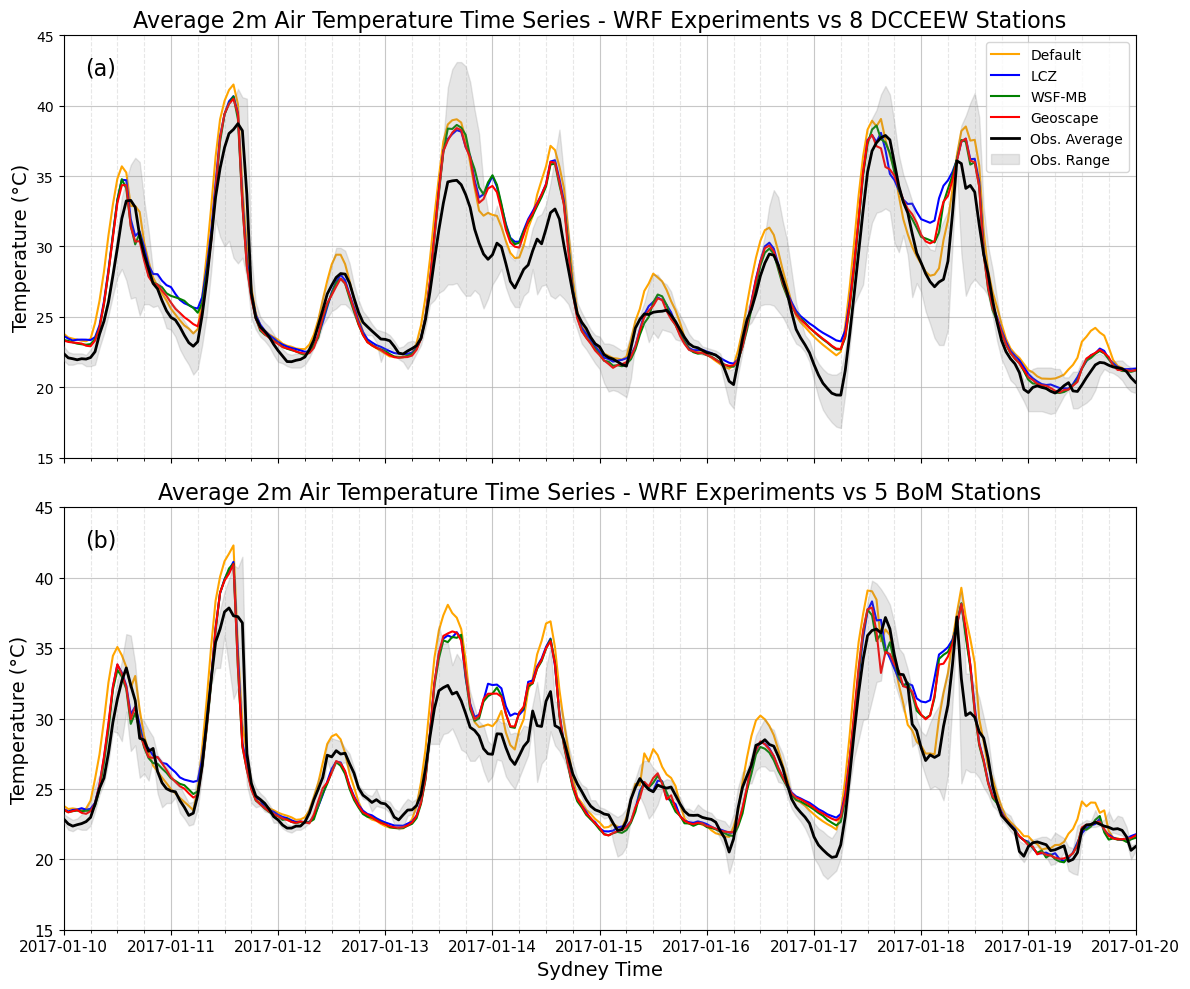

In [ ]:
line_colors = {
    'Default(Bulk+NoUCM)': 'orange',
    'LCZ': 'blue',
    'WSF-MB': 'green', 
    'Geoscape': 'red'
}

# Calculate BoM observational statistics
urban_data = []
for station in urbanaws:
    station_data = df_all_stations[df_all_stations['Station'] == station]
    urban_data.append(station_data.set_index('Time')[['Temperature']])

combined_data = pd.concat(urban_data, axis=1, keys=urbanaws)
combined_data.columns = combined_data.columns.get_level_values(1)

mean_temp_bom = combined_data.mean(axis=1)
min_temp_bom = combined_data.min(axis=1)
max_temp_bom = combined_data.max(axis=1)

# Calculate DCCEEW observational statistics
df_dcceew['Average'] = df_dcceew[station_cols_dcceew].mean(axis=1)
df_dcceew['Min'] = df_dcceew[station_cols_dcceew].min(axis=1)
df_dcceew['Max'] = df_dcceew[station_cols_dcceew].max(axis=1)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ========== TOP SUBPLOT: BoM Stations ==========
# Plot WRF scenarios
for sc in scenario:
    if sc == "Default(Bulk+NoUCM)":
        ax1.plot(average_t_dcceew['time'], average_t_dcceew[sc], label="Default", color=line_colors[sc])
    else:
        ax1.plot(average_t_dcceew['time'], average_t_dcceew[sc], label=sc, color=line_colors[sc])

# Plot observational average and range
ax1.plot(df_dcceew['Time'], df_dcceew['Average'], 
         color='black', label='Obs. Average', linewidth=2, zorder=10)
ax1.fill_between(df_dcceew['Time'], df_dcceew['Min'], df_dcceew['Max'], 
                 alpha=0.2, color='gray', label='Obs. Range', zorder=5)

ax1.set_ylabel("Temperature (°C)", fontsize=14)
ax1.set_ylim(15, 45)
ax1.set_title('Average 2m Air Temperature Time Series - WRF Experiments vs 8 DCCEEW Stations', fontsize=16)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax1.grid(True, which='minor', linestyle='--', alpha=0.3)
ax1.grid(True, which='major', linestyle='-', alpha=0.7)

# Add (a) label
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, fontsize=16, 
          va='top', ha='left')  #fontweight='bold',

# Set x-axis limits for both subplots
ax1.set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))


# ========== BOTTOM SUBPLOT: DCCEEW Stations ==========
# Plot WRF scenarios
for sc in scenario:
    if sc == "Default(Bulk+NoUCM)":
        ax2.plot(average_t_bom['time'], average_t_bom[sc], label="Default", color=line_colors[sc])
    else:
        ax2.plot(average_t_bom['time'], average_t_bom[sc], label=sc, color=line_colors[sc])

# Plot observational average and range
ax2.plot(mean_temp_bom.index, mean_temp_bom.values, 
         color='black', label='Obs. Avg.', linewidth=2, zorder=10)
ax2.fill_between(mean_temp_bom.index, min_temp_bom.values, max_temp_bom.values, 
                 alpha=0.2, color='gray', label='Obs. Range', zorder=5)

ax2.set_xlabel('Sydney Time', fontsize=14)
ax2.set_ylabel("Temperature (°C)", fontsize=14)
ax2.set_ylim(15, 45)
ax2.set_title('Average 2m Air Temperature Time Series - WRF Experiments vs 5 BoM Stations', fontsize=16)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax2.grid(True, which='minor', linestyle='--', alpha=0.3)
ax2.grid(True, which='major', linestyle='-', alpha=0.7)

# Add (b) label 
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, fontsize=16, 
         va='top', ha='left')  #fontweight='bold', 

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("/g/data/gb02/mf9078/plots/Fig4.png", dpi=300)
plt.show()